In [2]:
import os 
import sys

sys.path.append(os.path.dirname(os.getcwd()))

from env_constants import PYGARMENT_ROOT

sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg

from sewing_pattern import (
    Stitch, StitchDict, SVGPanel, SewingPattern,
    ParameterizedSeamLine, ParameterizedEdgeLine,
    UnconstrainedFewViewLabel
)

In [3]:
from glob import glob

garment_path_list = sorted(glob("../sample_data/*"))
garment_path_list

['../sample_data/dress_sleeveless_005CWF73E9__01',
 '../sample_data/dress_sleeveless_45V6ZGELXG__01',
 '../sample_data/dress_sleeveless_48R3G5YQID__01',
 '../sample_data/dress_sleeveless_4EI7RB9464__01',
 '../sample_data/dress_sleeveless_4JILJHEVIR__01',
 '../sample_data/dress_sleeveless_4R3PV1G9I0__01',
 '../sample_data/rand_6W3XGQZOE9',
 '../sample_data/rand_828KKFL4TS',
 '../sample_data/rand_8OFBWHKMNI__01__rand_XN21WM295Z__01',
 '../sample_data/rand_9048W5H2M7__01__rand_AE9AGPLS50__01',
 '../sample_data/rand_GBLADVC34S__01__rand_6AGC4UHTDZ__01',
 '../sample_data/rand_KFFMSBTCLN__01__rand_NREVPLXRB4__01',
 '../sample_data/rand_LYODEAC7GD__01__rand_NLVEL04PVV__01',
 '../sample_data/rand_NY8PDT0OHH__01__rand_X0RYYHT25Q__01',
 '../sample_data/rand_OAQ0JSHLO1__01__rand_U5CDI126UU__01',
 '../sample_data/rand_PMC1DC5RA8__01__rand_HPZQ55OXXC__01',
 '../sample_data/rand_QM1ESVZV2T__01__rand_MPOC4DJS72__01',
 '../sample_data/rand_R2ITQIWHJP',
 '../sample_data/rand_VUWCAG4VZP',
 '../sample_da

In [4]:
import pickle
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

[]

In [5]:
idx = 4

seam_annotation_path_list = sorted(glob(os.path.join(garment_path_list[idx], "*.pkl")))
seam_annotation_list = list(map(
    lambda x : pickle.load(open(x, "rb")),
    seam_annotation_path_list
))
image_list = list(map(
    lambda x : Image.open(x.replace("_seam_line.pkl", ".png")),
    seam_annotation_path_list
))

SPEC_PATH = list(filter(
    lambda x : "specification" in x,
    glob(
        os.path.join(
            os.path.dirname(seam_annotation_path_list[0]), "*.json"
        )
    )
))[0]

pattern = pyg.pattern.wrappers.VisPattern(SPEC_PATH)

panel_svg_path_dict = {
    panel_name : pattern._draw_a_panel(
        panel_name, apply_transform=False, fill=True
    )
    for panel_name in pattern.panel_order()
}
stitch_dict = {
    i : v for i, v in enumerate(pattern.pattern['stitches'])
}

sewing_pattern = SewingPattern(panel_svg_path_dict, stitch_dict)

sewing_pattern.draw(
    plot_panel_name = False,
    # plot_stitch_name = False
)


IndexError: list index out of range

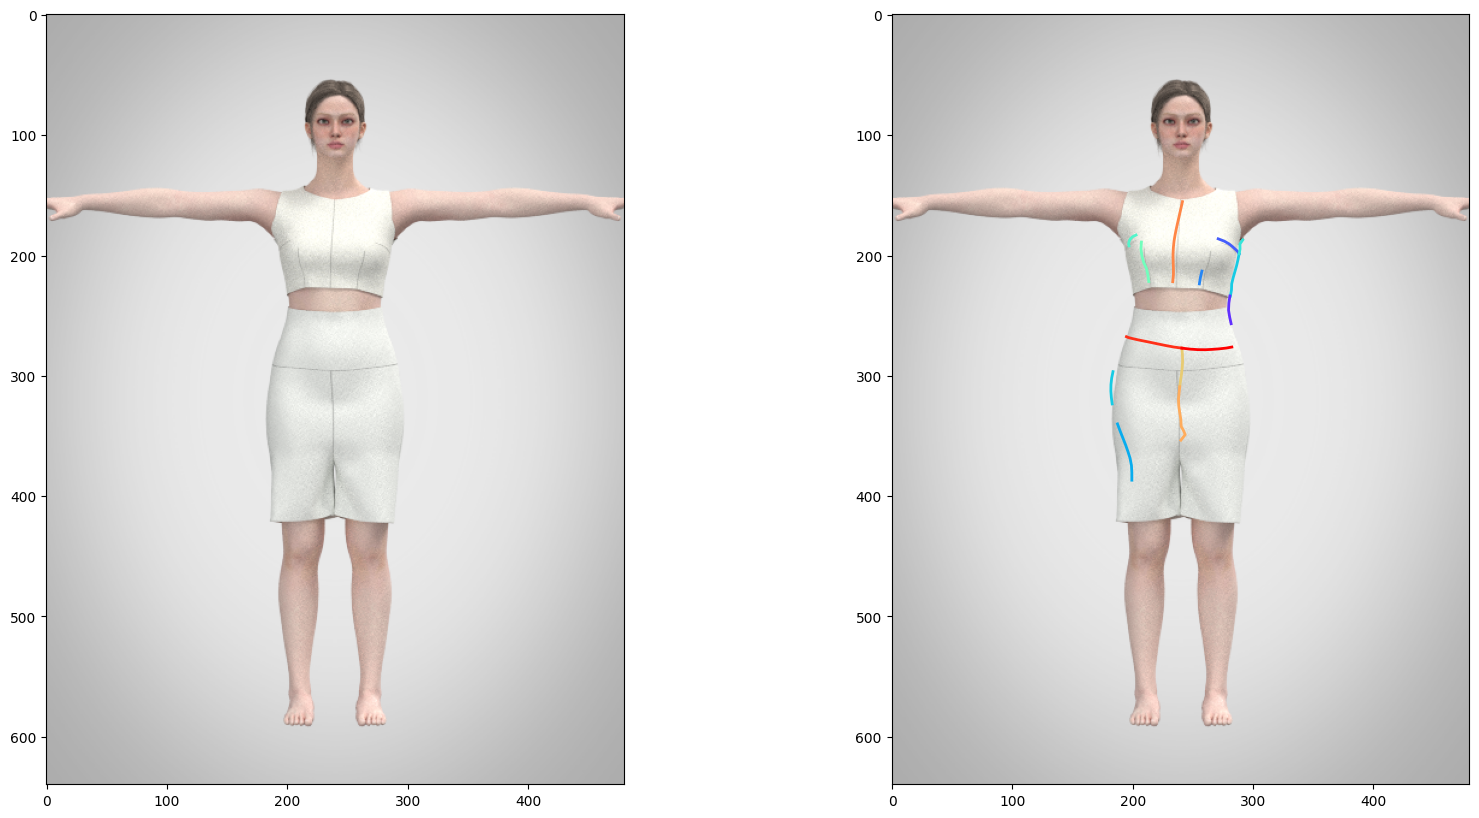

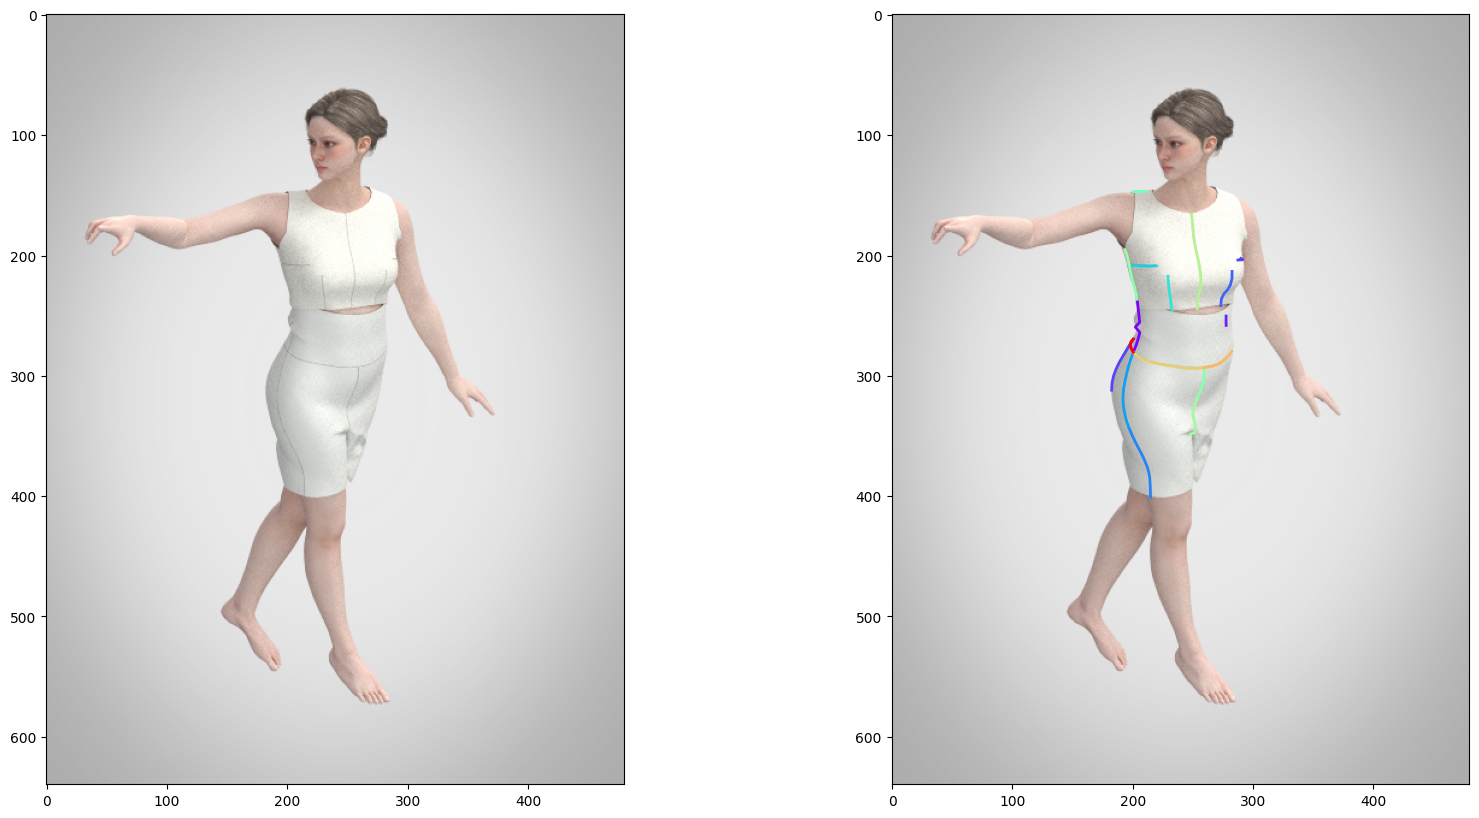

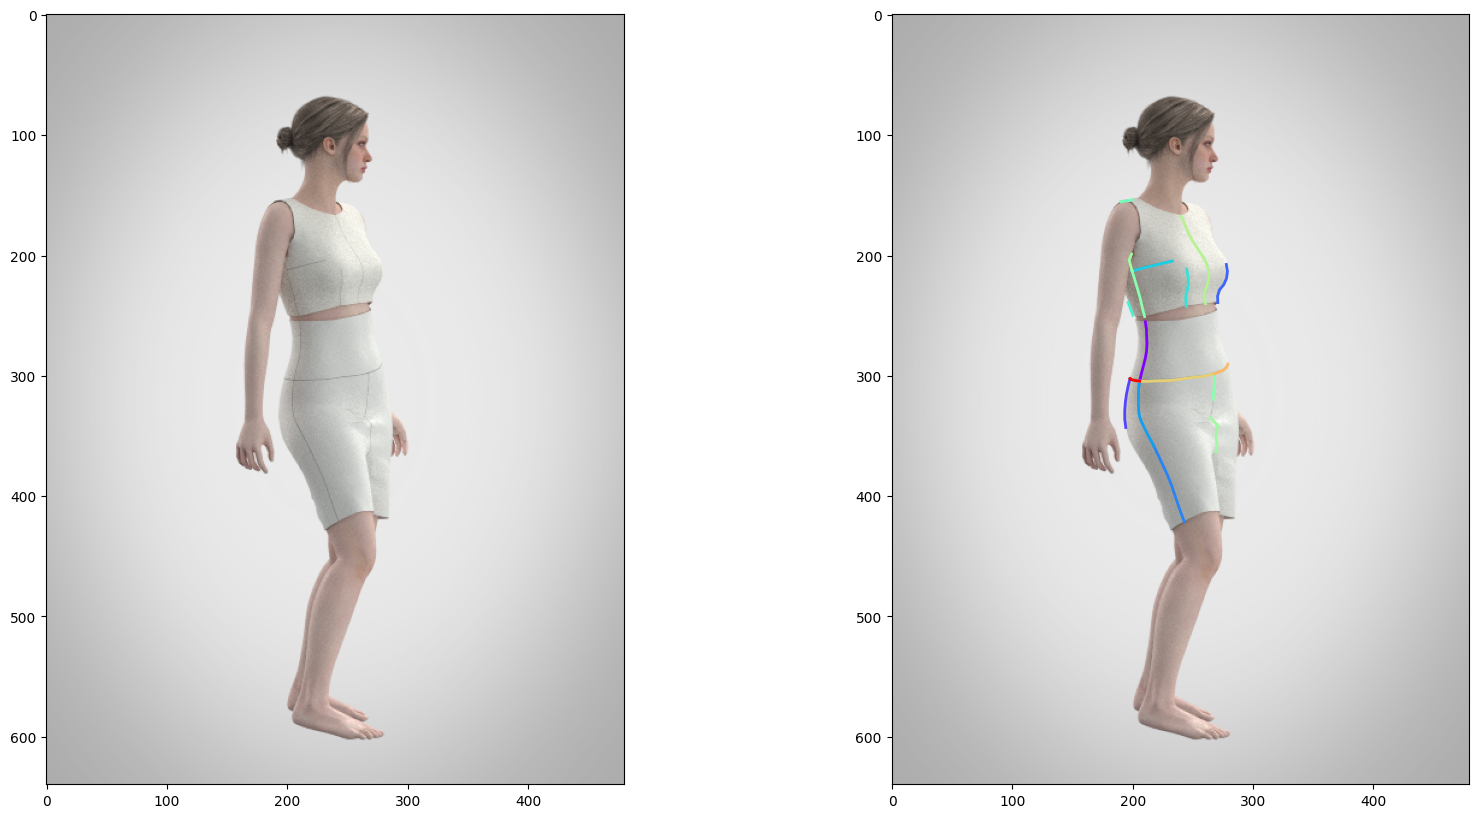

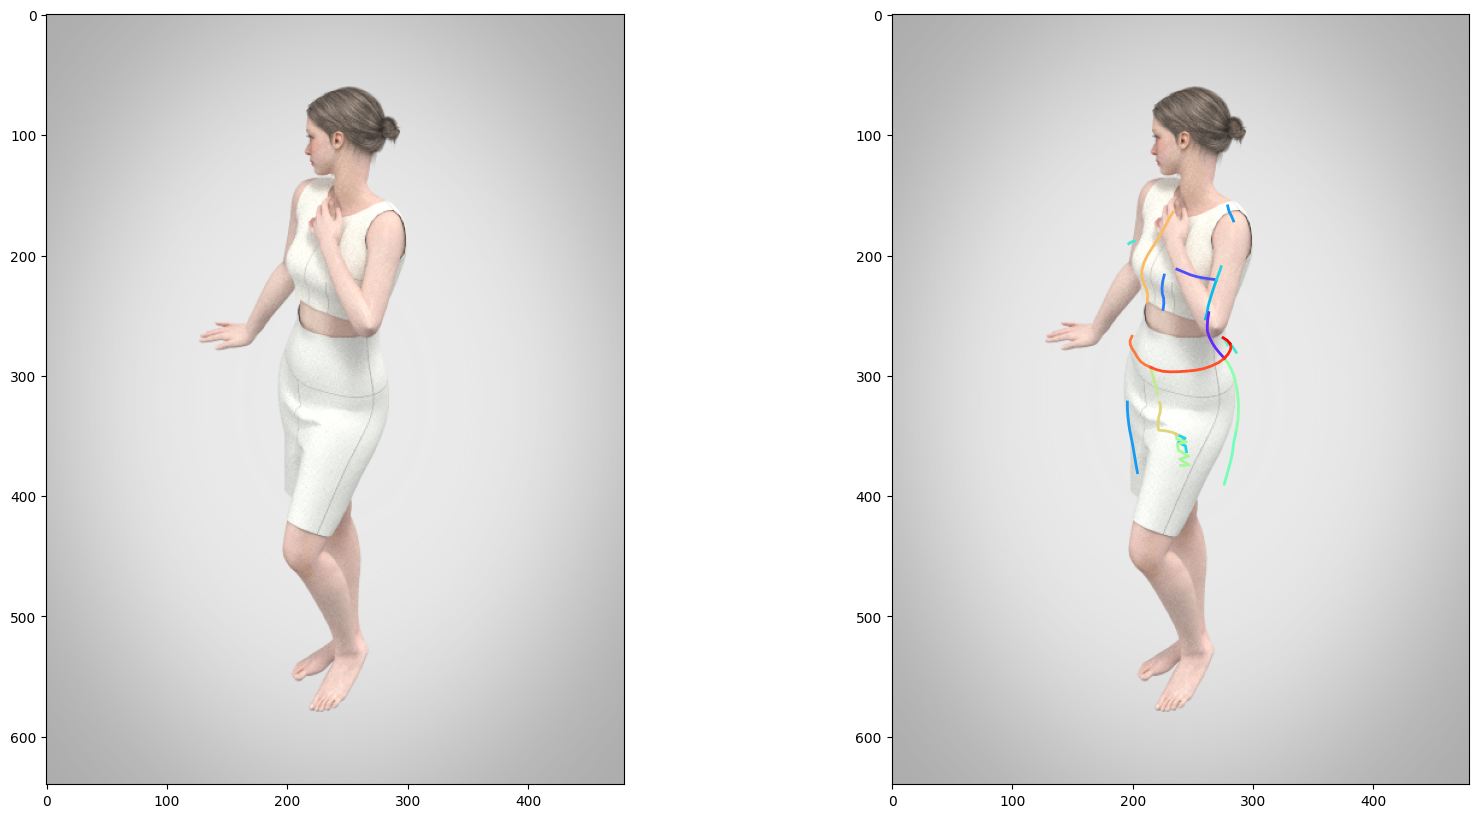

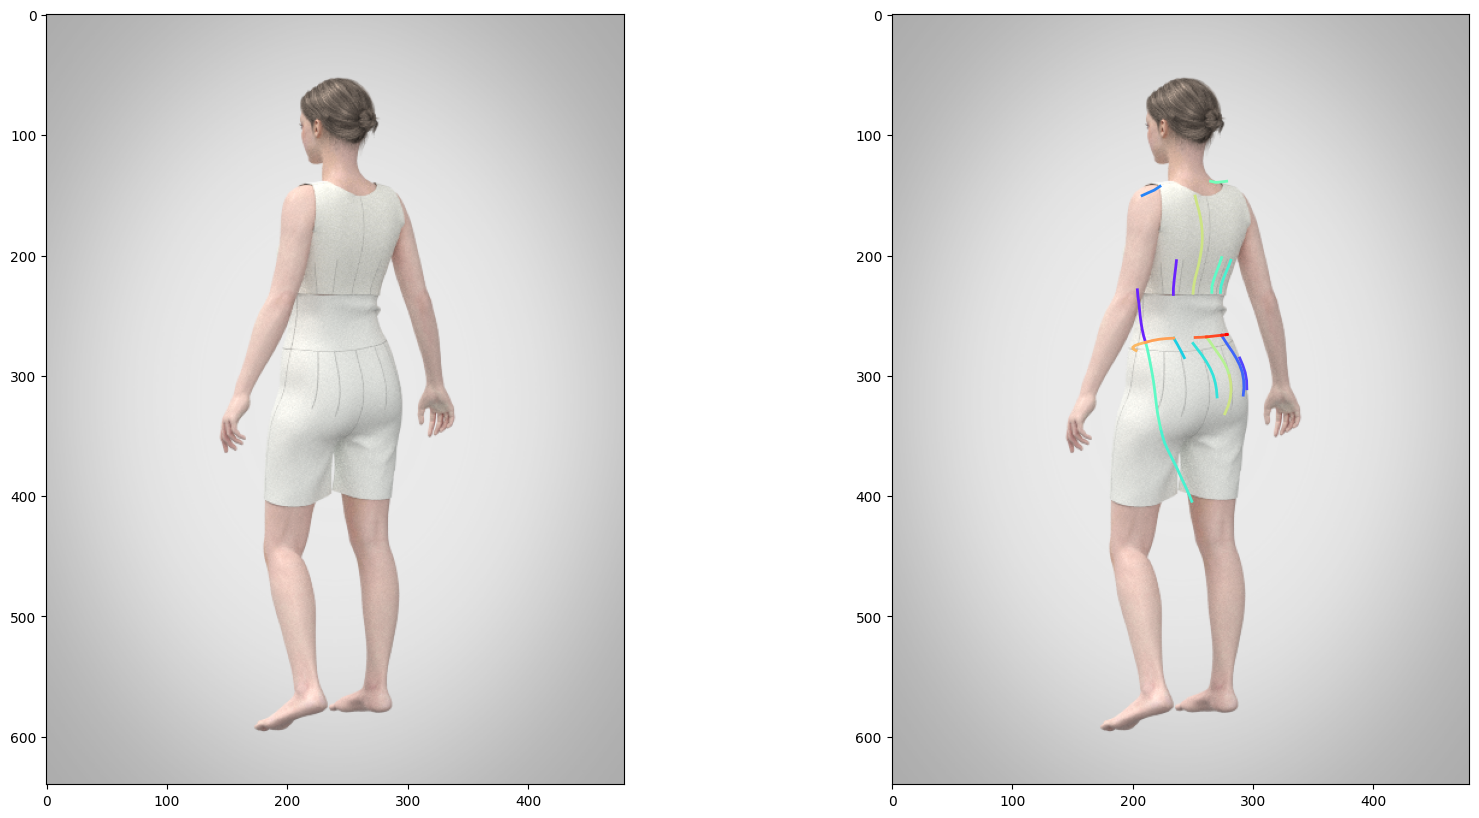

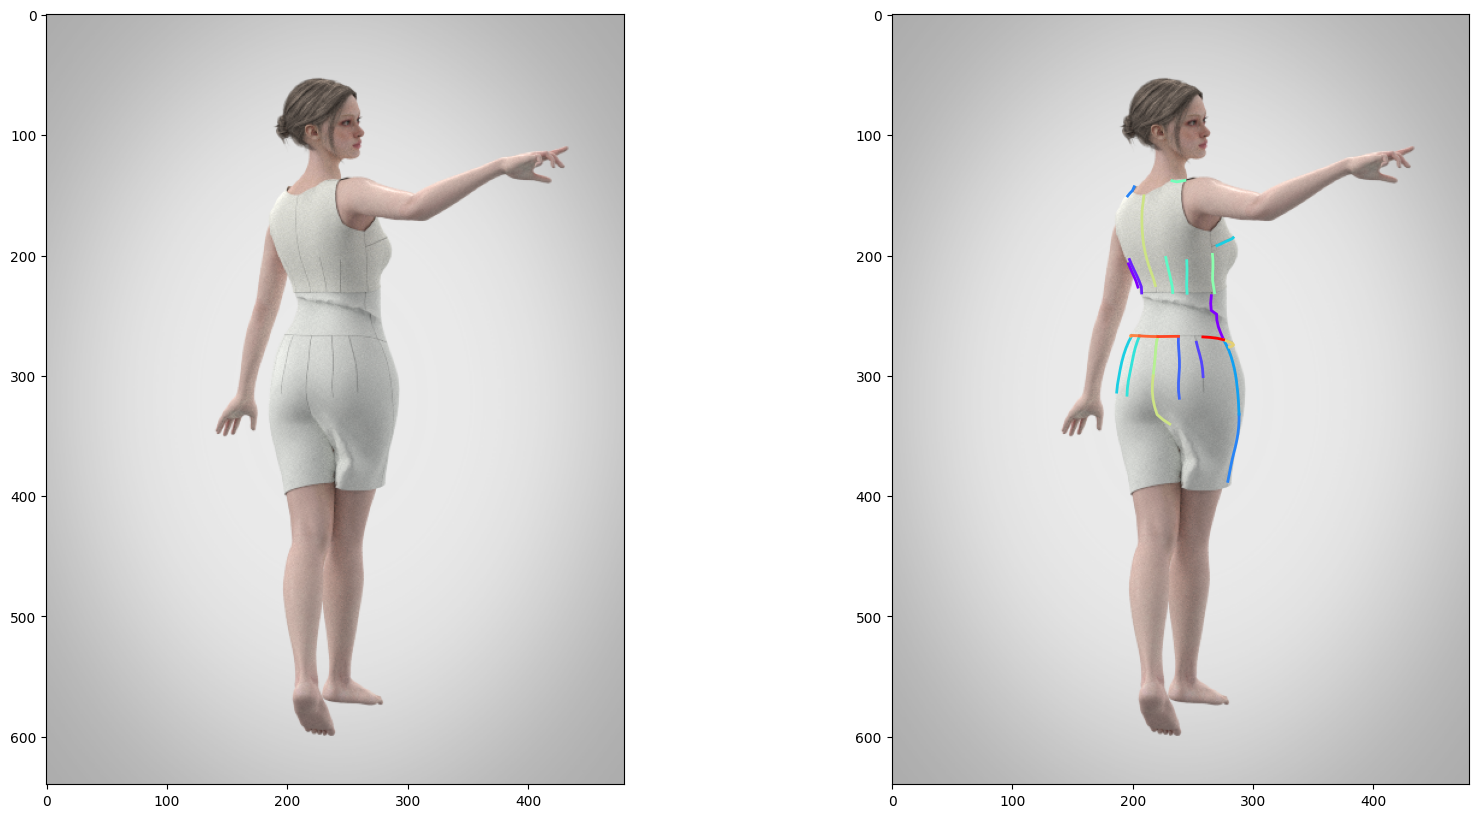

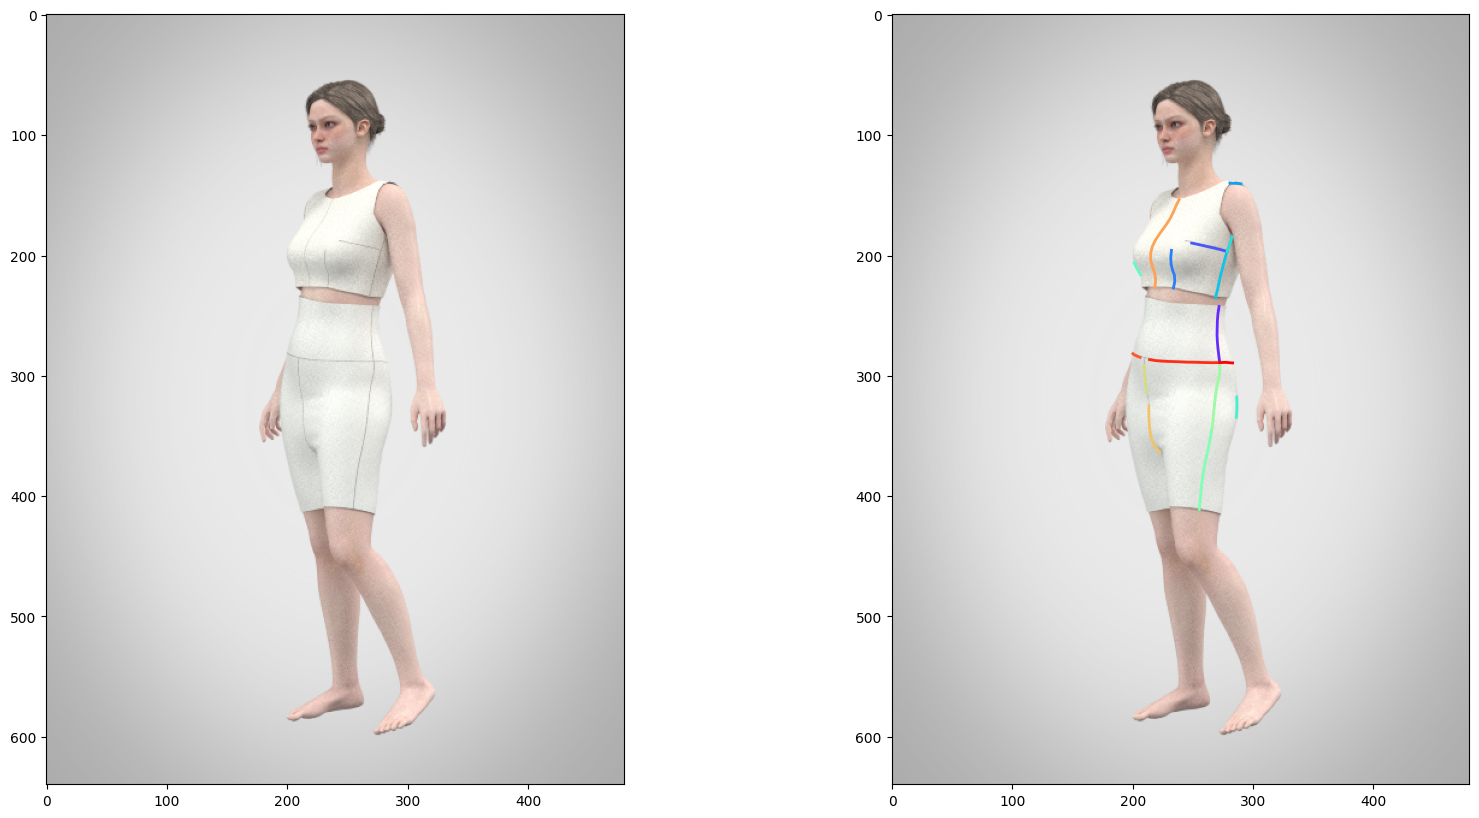

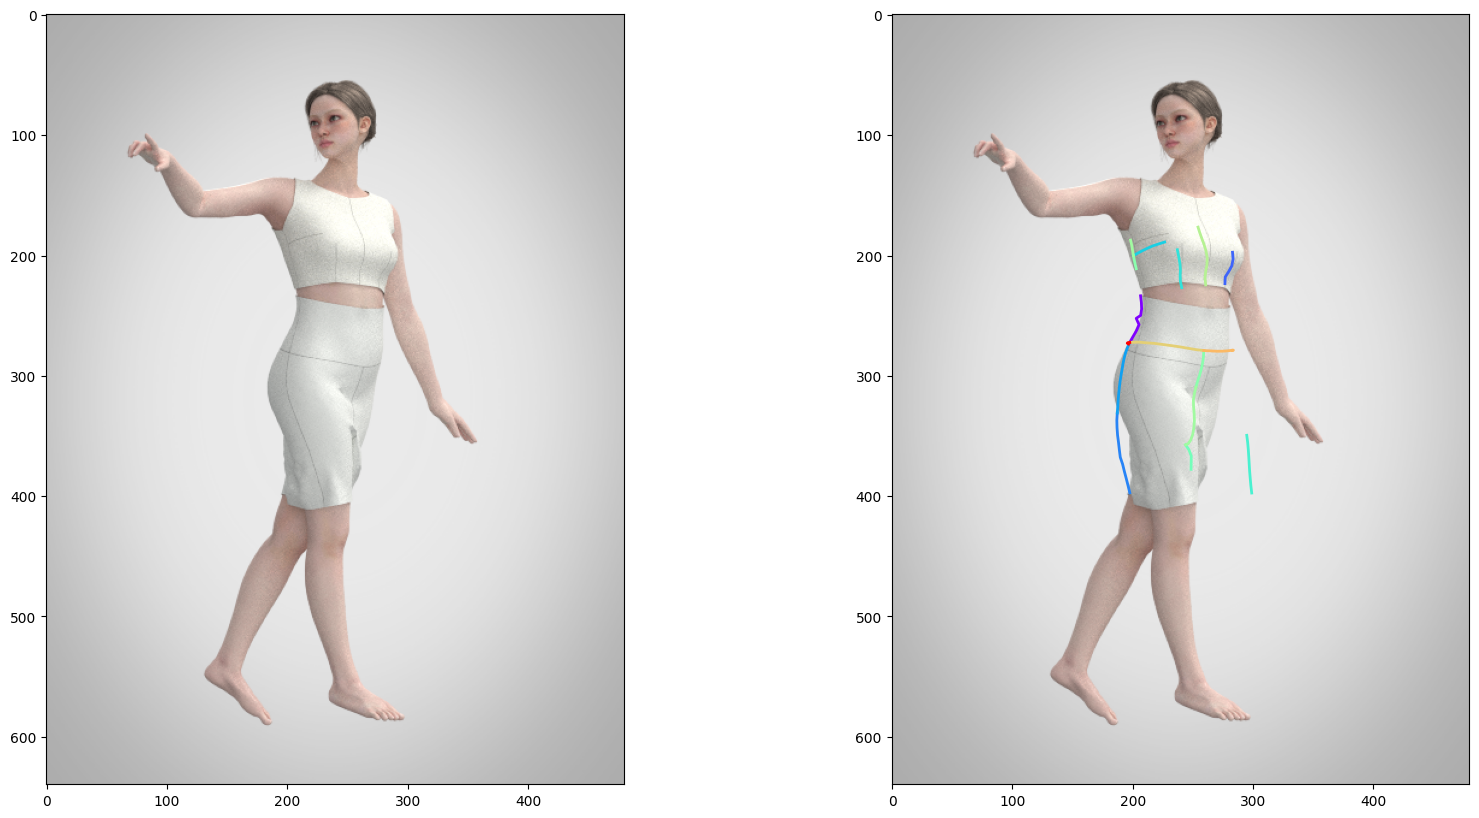

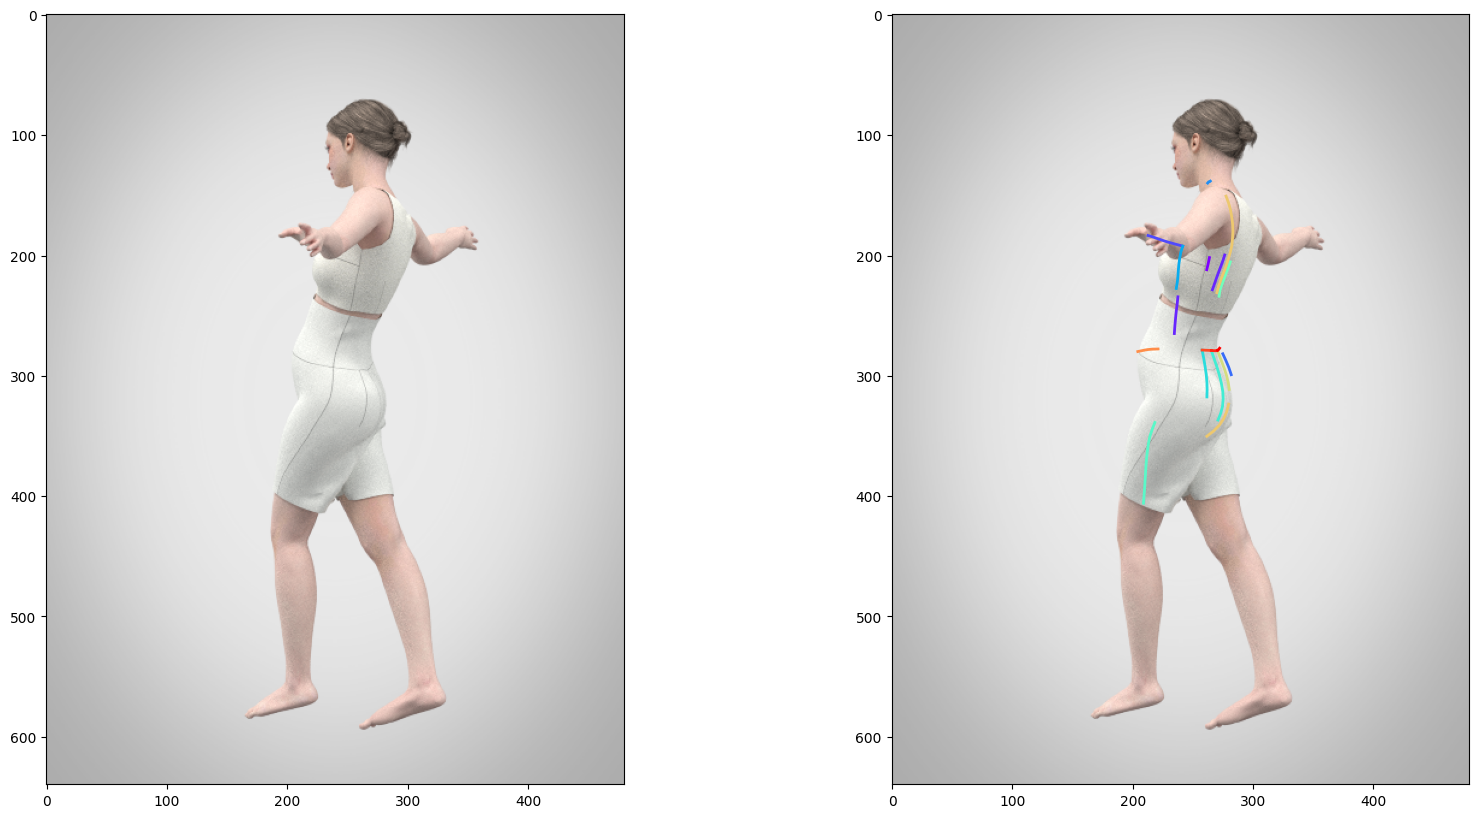

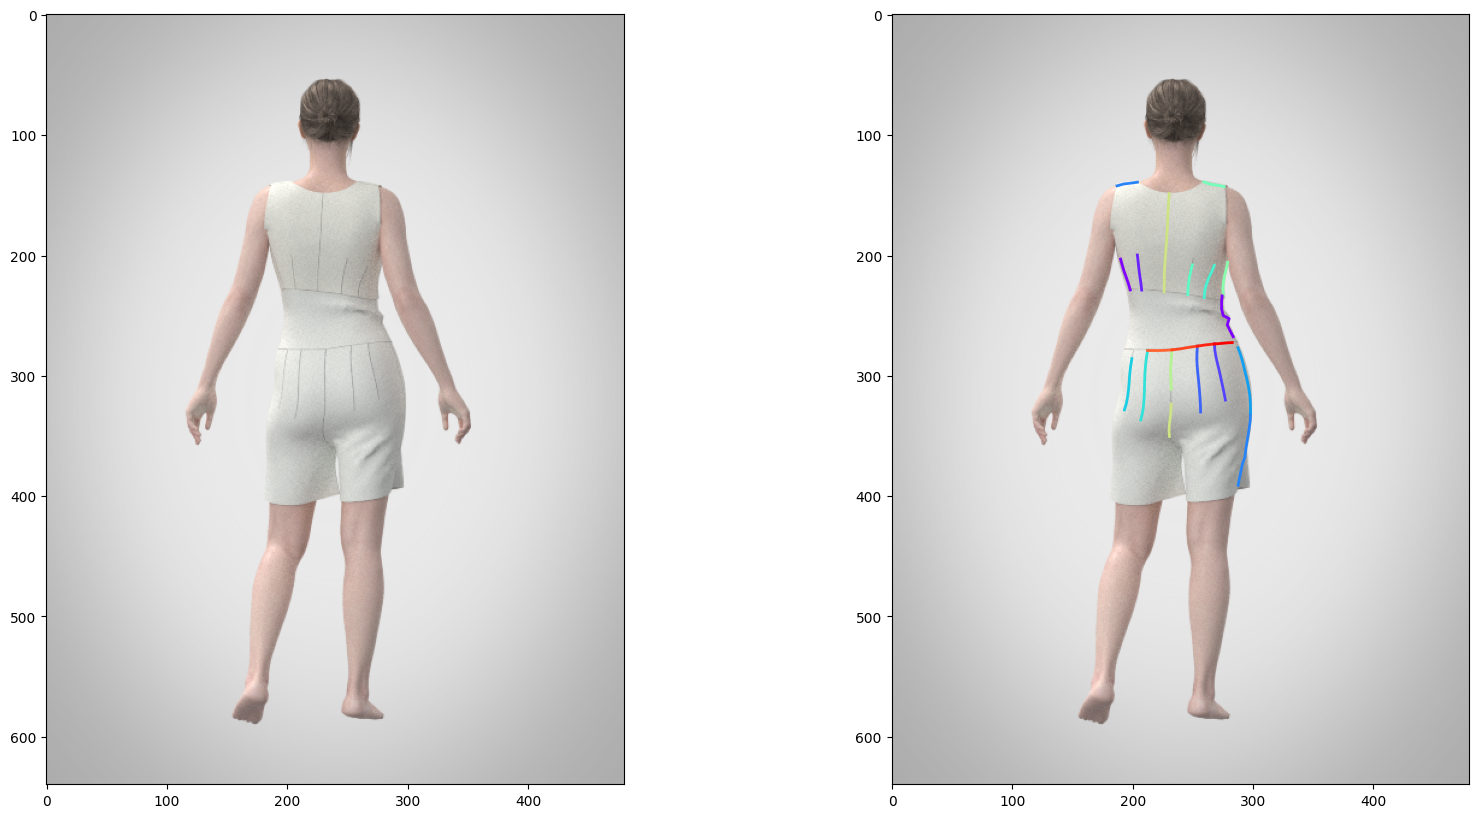

In [11]:

FIGSIZE = 10
NROWS = 1
NCOLS = 2

for i in range(len(seam_annotation_list)) :
    visible_seam_line_dict_dict = seam_annotation_list[i]
    img = image_list[i]
    
    STCH_IDX_MAX = max(
        list(map(
            lambda stch_dict : max(list(stch_dict.keys())),
            visible_seam_line_dict_dict.values()
        ))
    )
    colors = plt.cm.rainbow(np.linspace(0, 1, STCH_IDX_MAX + 1))
    
    plt.figure(figsize=(FIGSIZE*NCOLS, FIGSIZE*NROWS))
    ax1 = plt.subplot(NROWS, NCOLS, 1)
    ax1.imshow(img)

    ax2 = plt.subplot(NROWS, NCOLS, 2)
    ax2.imshow(img)


    for garment_id in visible_seam_line_dict_dict.keys() :
        for stch_idx, visible_seam_line_info in visible_seam_line_dict_dict[garment_id].items() :
            for (
                segment_idx_arr, segment_pos_arr, segment_edge_len_arr, segment_t_arr, segment_u_arr, segment_v_arr
            ) in zip(
                visible_seam_line_info["segment_idx_arr_list"],
                visible_seam_line_info["segment_pos_arr_list"],
                visible_seam_line_info["segment_edge_len_arr_list"],
                visible_seam_line_info["segment_t_arr_list"],
                visible_seam_line_info["segment_u_arr_list"],
                visible_seam_line_info["segment_v_arr_list"]
            ) :
                i_vec = segment_pos_arr[-1] - segment_pos_arr[0]
                j_vec = np.array([i_vec[1], -i_vec[0]])
                
                ax2.plot(
                    segment_pos_arr[:, 0],
                    segment_pos_arr[:, 1],
                    color=colors[stch_idx],
                    linewidth=2
                )
                
    plt.show()